In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

%matplotlib inline

In [2]:
datos = pd.read_csv(filepath_or_buffer = "/Users/paola/Desktop/DE2_Regresión Ridge/beisbol.csv",sep=',',low_memory=False)

In [3]:
datos

,Unnamed: 0,equipos,bateos,runs
0,0,Texas,5659,855
1,1,Boston,5710,875
2,2,Detroit,5563,787
3,3,Kansas,5672,730
4,4,St.,5532,762
5,5,New_S.,5600,718
6,6,New_Y.,5518,867
7,7,Milwaukee,5447,721
8,8,Colorado,5544,735
9,9,Houston,5598,615


In [5]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  30 non-null     int64
 1   equipos     30 non-null     str  
 2   bateos      30 non-null     int64
 3   runs        30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB


In [6]:
datos.describe()

,Unnamed: 0,bateos,runs
count,30.000000,30.000000,30.000000
mean,14.500000,5523.500000,693.600000
std,8.803408,79.873067,82.479088
min,0.000000,5417.000000,556.000000
25%,7.250000,5448.250000,629.000000
50%,14.500000,5515.500000,705.500000
75%,21.750000,5575.000000,734.000000
max,29.000000,5710.000000,875.000000


In [7]:
datos.isnull().sum()

Unnamed: 0    0
equipos       0
bateos        0
runs          0
dtype: int64

In [8]:
print("Datos duplicados:", datos.duplicated().sum())

Datos duplicados: 0


In [9]:
datos = datos.drop(columns=["Unnamed: 0"])

datos

,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762
5,New_S.,5600,718
6,New_Y.,5518,867
7,Milwaukee,5447,721
8,Colorado,5544,735
9,Houston,5598,615


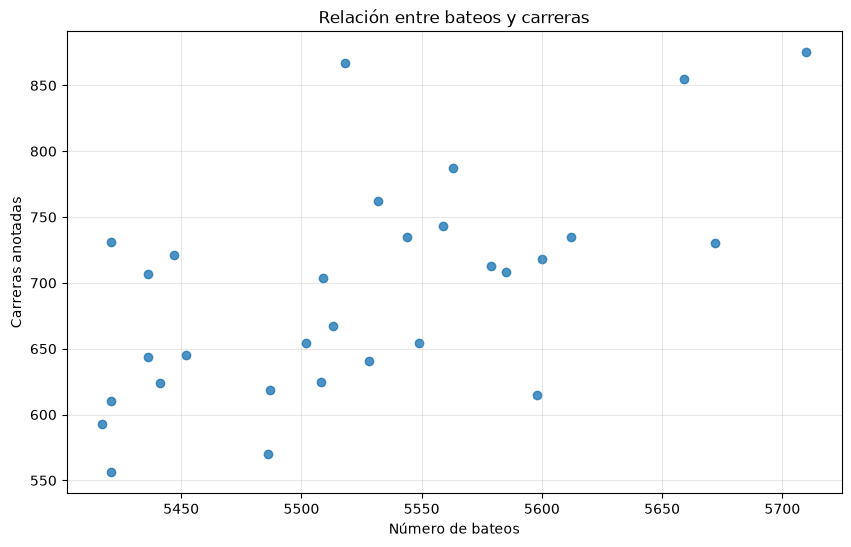

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(
    datos["bateos"],
    datos["runs"],
    alpha=0.8
)

plt.title("Relación entre bateos y carreras")
plt.xlabel("Número de bateos")
plt.ylabel("Carreras anotadas")
plt.grid(alpha=0.3)

plt.show()

In [11]:
X = datos[["bateos"]]
y = datos["runs"]

In [12]:
print("X:", X.shape)
print("y:", y.shape)

X: (30, 1)
y: (30,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

In [14]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (24, 1)
Datos de prueba: (6, 1)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
modelo = Ridge(
    alpha=1.0
)

modelo.fit(
    X_train_scaled,
    y_train
)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [17]:
print("Intercepto:", modelo.intercept_)
print("Coeficiente:", modelo.coef_)

Intercepto: 693.9166666666666
Coeficiente: [47.79735767]


In [18]:
y_pred = modelo.predict(
    X_test_scaled
)

y_pred

array([715.92295847, 626.36425177, 745.98033263, 729.41810605,
       641.08623095, 638.01915195])

In [19]:
resultados = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred
})

resultados

,Real,Predicho
0,787,715.922958
1,593,626.364252
2,735,745.980333
3,708,729.418106
4,624,641.086231
5,707,638.019152


In [20]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 37.15113516369335
MSE: 1965.7864643171517
RMSE: 44.33719053252192
R²: 0.5424738633309791


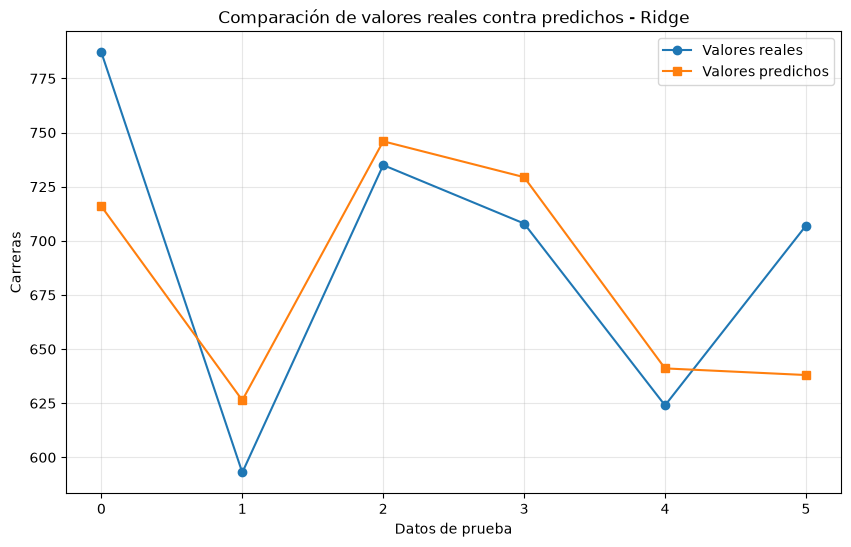

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(len(y_test)),
    y_test.values,
    marker="o",
    label="Valores reales"
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker="s",
    label="Valores predichos"
)

plt.title("Comparación de valores reales contra predichos - Ridge")
plt.xlabel("Datos de prueba")
plt.ylabel("Carreras")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

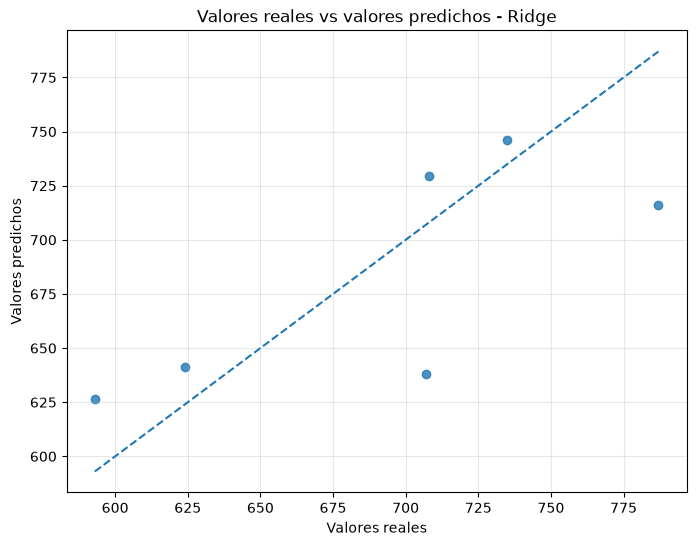

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.8
)

min_valor = min(
    y_test.min(),
    y_pred.min()
)

max_valor = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_valor, max_valor],
    [min_valor, max_valor],
    linestyle="--"
)

plt.title("Valores reales vs valores predichos - Ridge")
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.grid(alpha=0.3)

plt.show()

In [23]:
parametros = {
    "alpha": [
        0.001,
        0.01,
        0.1,
        0.5,
        1,
        5,
        10,
        50,
        100,
        500,
        1000
    ],
    "fit_intercept": [
        True,
        False
    ]
}

In [24]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=1
)

In [25]:
busqueda = GridSearchCV(
    estimator=Ridge(),
    param_grid=parametros,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=1
)

In [26]:
resultado_grid = busqueda.fit(
    X_train_scaled,
    y_train
)

In [27]:
print(
    "Mejor puntuación:",
    resultado_grid.best_score_
)

print(
    "Mejores hiperparámetros:",
    resultado_grid.best_params_
)

Mejor puntuación: -5295.035426412373
Mejores hiperparámetros: {'alpha': 1, 'fit_intercept': True}


In [28]:
modelo_optimizado = resultado_grid.best_estimator_

In [29]:
y_pred_opt = modelo_optimizado.predict(
    X_test_scaled
)

y_pred_opt

array([715.92295847, 626.36425177, 745.98033263, 729.41810605,
       641.08623095, 638.01915195])

In [30]:
mae_opt = mean_absolute_error(
    y_test,
    y_pred_opt
)

mse_opt = mean_squared_error(
    y_test,
    y_pred_opt
)

rmse_opt = np.sqrt(mse_opt)

r2_opt = r2_score(
    y_test,
    y_pred_opt
)

print("MAE optimizado:", mae_opt)
print("MSE optimizado:", mse_opt)
print("RMSE optimizado:", rmse_opt)
print("R² optimizado:", r2_opt)

MAE optimizado: 37.15113516369335
MSE optimizado: 1965.7864643171517
RMSE optimizado: 44.33719053252192
R² optimizado: 0.5424738633309791


In [31]:
comparacion = pd.DataFrame({
    "Métrica": [
        "MAE",
        "MSE",
        "RMSE",
        "R²"
    ],
    "Modelo original": [
        mae,
        mse,
        rmse,
        r2
    ],
    "Modelo optimizado": [
        mae_opt,
        mse_opt,
        rmse_opt,
        r2_opt
    ]
})

comparacion

,Métrica,Modelo original,Modelo optimizado
0,MAE,37.151135,37.151135
1,MSE,1965.786464,1965.786464
2,RMSE,44.337191,44.337191
3,R²,0.542474,0.542474


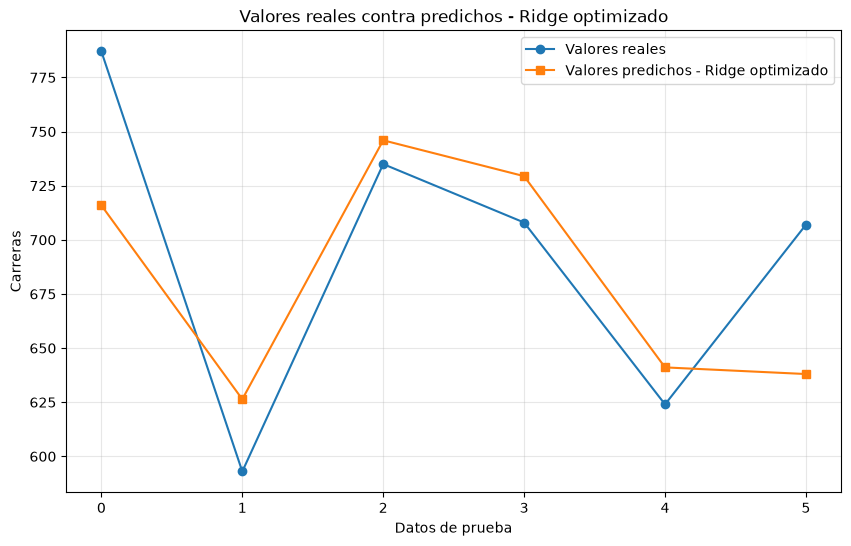

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(len(y_test)),
    y_test.values,
    marker="o",
    label="Valores reales"
)

plt.plot(
    range(len(y_pred_opt)),
    y_pred_opt,
    marker="s",
    label="Valores predichos - Ridge optimizado"
)

plt.title("Valores reales contra predichos - Ridge optimizado")
plt.xlabel("Datos de prueba")
plt.ylabel("Carreras")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [33]:
modelo_final = {
    "scaler": scaler,
    "modelo": modelo_optimizado
}

joblib.dump(
    modelo_final,
    "modelo_ridge_beisbol.pkl"
)

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [34]:
modelo_cargado = joblib.load(
    "modelo_ridge_beisbol.pkl"
)

scaler_cargado = modelo_cargado["scaler"]
ridge_cargado = modelo_cargado["modelo"]

X_test_cargado = scaler_cargado.transform(X_test)

predicciones_prueba = ridge_cargado.predict(
    X_test_cargado
)

print(predicciones_prueba)

[715.92295847 626.36425177 745.98033263 729.41810605 641.08623095
 638.01915195]


In [35]:
resultados_finales = pd.DataFrame({
    "Valor real": y_test.values,
    "Valor predicho": y_pred_opt,
    "Error": y_test.values - y_pred_opt
})

resultados_finales

,Valor real,Valor predicho,Error
0,787,715.922958,71.077042
1,593,626.364252,-33.364252
2,735,745.980333,-10.980333
3,708,729.418106,-21.418106
4,624,641.086231,-17.086231
5,707,638.019152,68.980848


In [36]:
resultados_finales.to_csv(
    "resultados_ridge_beisbol.csv",
    index=False
)

print("Resultados guardados correctamente")

Resultados guardados correctamente
